Date: 24/06/2024 <br>
Desc: To test for the failure condition for height adaptation (where adjusting the height causes the UAV to go through stages where it can fail).

## Imports

In [3]:
import tensorflow as tf
from keras import activations
from keras import backend as K
from keras.models import Model
from keras.layers import Dense, Input
import pandas as pd # for data manipulation 
import numpy as np
import math, os
from scipy import special
import xml.etree.ElementTree as ET
from bs4 import BeautifulSoup 

def euclidean_dist(row):
    # Function to calc euclidean distance on every df row 
    euc_dist = math.sqrt(row["U2G_Distance"]**2 - row["Height"]**2)
    return euc_dist

def q_func(x):
    q = 0.5 - 0.5*special.erf(x / np.sqrt(2))
    return q

def friis_calc(P,freq,dist,ple):
    '''
    Friis path loss equation
    P = Tx transmit power
    freq = Signal frequency
    dist = Transmission distance
    ple = Path loss exponent
    '''
    propagation_speed = 299792458
    l = propagation_speed / freq
    h_pl = P * l**2 / (16*math.pi**2)
    P_Rx = h_pl * dist**(-ple)
    return P_Rx

def plos_calc(h_dist, height_tx, height_rx, env='suburban'):
    '''
    % This function implements the LoS probability model from the paper
    % "Blockage Modeling for Inter-layer UAVs Communications in Urban
    % Environments" 
    % param h_dist    : horizontal distance between Tx and Rx (m)
    % param height_tx : height of Tx
    % param height_rx : height of Rx
    '''
    if env == 'suburban':
        a1 = 0.1
        a2 = 7.5e-4
        a3 = 8
    elif env == 'urban':
        a1 = 0.3
        a2 = 5e-4
        a3 = 15
    
    delta_h = height_tx - height_rx
    # pow_factor = 2 * h_dist * math.sqrt(a1*a2/math.pi) + a1 # NOTE: Use this pow_factor if assuming PPP building dist.
    pow_factor = h_dist * math.sqrt(a1*a2) # NOTE: Use this pow_factor if assuming ITU-R assumptions.
    if delta_h == 0:
        p = (1 - math.exp((-(height_tx)**2) / (2*a3**2))) ** pow_factor
    else:
        if delta_h < 0:
            h1 = height_rx
            h2 = height_tx
        else:
            h1 = height_tx
            h2 = height_rx
        delta_h = abs(delta_h)
        p = (1 - (math.sqrt(2*math.pi)*a3 / delta_h) * abs(q_func(h1/a3) - q_func(h2/a3))) ** pow_factor
    return p

def sinr_lognormal_approx(h_dist, height, env='suburban'):
    '''
    To approximate the SNR from signal considering multipath fading and shadowing
    Assuming no interference due to CSMA, and fixed noise
    Inputs:
    h_dist = Horizontal Distance between Tx and Rx
    height = Height difference between Tx and Rx
    env = The operating environment (currently only suburban supported)
    '''
    # Signal properties
    P_Tx_dBm = 20 # Transmit power of 
    P_Tx = 10**(P_Tx_dBm/10) / 1000
    freq = 2.4e9 # Channel frequency (Hz)
    noise_dBm = -86
    noise = 10**(noise_dBm/10) / 1000
    if env == "suburban":
        # ENV Parameters Constants ----------------------------------
        # n_min = 2
        # n_max = 2.75
        # K_dB_min = 7.8
        # K_dB_max = 17.5
        # K_min = 10**(K_dB_min/10)
        # K_max = 10**(K_dB_max/10)
        # alpha = 11.25 # Env parameters for logarithm std dev of shadowing 
        # beta = 0.06 # Env parameters for logarithm std dev of shadowing 
        n_min = 2
        n_max = 2.75
        K_dB_min = 1.4922
        K_dB_max = 12.2272
        K_min = 10**(K_dB_min/10)
        K_max = 10**(K_dB_max/10)
        alpha = 11.1852 # Env parameters for logarithm std dev of shadowing 
        beta = 0.06 # Env parameters for logarithm std dev of shadowing 
        # -----------------------------------------------------------
    elif env == "urban":
        n_min = 1.9
        n_max = 2.7
        K_dB_min = -5
        K_dB_max = 15
        K_min = 10**(K_dB_min/10)
        K_max = 10**(K_dB_max/10)
        alpha = 10.42 # Env parameters for logarithm std dev of shadowing 
        beta = 0.05 # Env parameters for logarithm std dev of shadowing 
    # Calculate fading parameters
    PLoS = plos_calc(h_dist, 0, height, env=env)
    theta_Rx = math.atan2(height, h_dist) * 180 / math.pi # Elevation angle in degrees
    ple = (n_min - n_max) * PLoS + n_max # Path loss exponent
    sigma_phi_dB = alpha*math.exp(-beta*theta_Rx)
    sigma_phi = 10**(sigma_phi_dB/10) # Logarithmic std dev of shadowing
    K = K_min * math.exp(math.log(K_max/K_min) * PLoS**2)
    omega = 1 # Omega of NCS (Rician)
    dist = math.sqrt(h_dist**2 + height**2)
    P_Rx = friis_calc(P_Tx, freq, dist, ple)
    # Approximate L-NCS RV (which is the SNR) as lognormal
    eta = math.log(10) / 10
    mu_phi = 10*math.log10(P_Rx)
    E_phi = math.exp(eta*mu_phi + eta**2*sigma_phi**2/2) # Mean of shadowing RV
    var_phi = math.exp(2*eta*mu_phi+eta**2*sigma_phi**2)*(math.exp(eta**2*sigma_phi**2)-1) # Variance of shadowing RV
    E_chi = (special.gamma(1+1)/(1+K))*special.hyp1f1(-1,1,-K)*omega
    var_chi = (special.gamma(1+2)/(1+K)**2)*special.hyp1f1(-2,1,-K)*omega**2 - E_chi**2
    E_SNR = E_phi * E_chi / noise # Theoretical mean of SINR
    var_SNR = ((var_phi+E_phi**2)*(var_chi+E_chi**2) - E_phi**2 * E_chi**2) / noise**2
    std_dev_SNR = math.sqrt(var_SNR)
    # sigma_ln = math.sqrt(math.log(var_SNR/E_SNR**2 + 1))
    # mu_ln = math.log(E_SNR) - sigma_ln**2/2
    return E_SNR, std_dev_SNR

def normalize_data(df, columns=[], save_details_path=None):
    '''
    columns: The pandas data columns to normalize, given as a list of column names
    '''
    # Define the ranges of parametrers
    max_mean_sinr = 10*math.log10(1123) # The max mean SINR calculated at (0,60) is 1122.743643457063 (linear)
    max_std_dev_sinr = 10*math.log10(466) # The max std dev SINR calculated at (0,60) is 465.2159856885714 (linear)
    min_mean_sinr = 10*math.log10(0.2) # The min mean SINR calculated at (1200,60) is 0.2251212887895188 (linear)
    min_std_dev_sinr = 10*math.log10(0.7) # The min std dev SINR calculated at (1200,300) is 0.7160093126585219 (linear)
    max_height = 300
    min_height = 60
    max_h_dist = 1200
    min_h_dist = 0

    # Normalize data (Min Max Normalization between [-1,1])
    if "Height" in columns:
        df["Height"] = df["Height"].apply(lambda x: 2*(x-min_height)/(max_height-min_height) - 1)
    if "U2G_H_Dist" in columns:
        df["U2G_H_Dist"] = df["U2G_H_Dist"].apply(lambda x: 2*(x-min_h_dist)/(max_h_dist-min_h_dist) - 1)
    if "Mean_SINR" in columns:
        df["Mean_SINR"] = df["Mean_SINR"].apply(lambda x: 2*(10*math.log10(x)-min_mean_sinr)/(max_mean_sinr-min_mean_sinr) - 1) # Convert to dB space
    if "Std_Dev_SINR" in columns:
        df["Std_Dev_SINR"] = df["Std_Dev_SINR"].apply(lambda x: 2*(10*math.log10(x)-min_std_dev_sinr)/(max_std_dev_sinr-min_std_dev_sinr) - 1) # Convert to dB space
    if "UAV_Sending_Interval" in columns:
        df["UAV_Sending_Interval"] = df["UAV_Sending_Interval"].replace({10:-1, 20:-0.5, 40:0, 66.7: 0.5, 100:1, 1000:2})
    if "Packet_State" in columns:
        df['Packet_State'] = df['Packet_State'].replace({"Reliable":0, "QUEUE_OVERFLOW":1, "RETRY_LIMIT_REACHED":2, "Delay_Exceeded":3})
    if "Modulation" in columns:
        df['Modulation'] = df['Modulation'].replace({"BPSK":1, "QPSK":0.3333, 16:-0.3333, "QAM-16":-0.3333, "QAM16":-0.3333, 64:-1, "QAM-64":-1, "QAM64":-1})

    # Record details of inputs and output for model
    if save_details_path is not None:
        f = open(os.path.join(save_details_path,"model_details.txt"), "w")
        f.write("Max Height (m): {}\n".format(max_height))
        f.write("Min Height (m): {}\n".format(min_height))
        f.write("Max H_Dist (m): {}\n".format(max_h_dist))
        f.write("Min H_Dist (m): {}\n".format(min_h_dist))
        f.write("Max Mean SINR (dB): {}\n".format(max_mean_sinr))
        f.write("Min Mean SINR (dB): {}\n".format(min_mean_sinr))
        f.write("Max Std Dev SINR (dB): {}\n".format(max_std_dev_sinr))
        f.write("Min Std Dev SINR (dB): {}\n".format(min_std_dev_sinr))
        f.write("[BPSK: 1, QPSK: 0.3333, QAM16: -0.3333, QAM64: -1]\n")
        f.write("UAV Sending Interval: [10:-1, 20:-0.5, 40:0, 100:0.5, 1000:1]\n")
        f.write("Output: ['Reliable':0, 'QUEUE_OVERFLOW':1, 'RETRY_LIMIT_REACHED':2, 'Delay_Exceeded':3]\n")
        f.close()

    return df

def norm_MCS(mcs_index):
    return 2*mcs_index/7 - 1

def build_nn_model_v4_wobatchnorm_noactivation():
    # For multiple output model
    # Version 4: Having only a single output layer for packet state
    inputs = Input(shape=(4,))
    base = Dense(100, activation='relu')(inputs)
    base = Dense(50, activation='relu')(base)
    base = Dense(25, activation='relu')(base)
    base = Dense(10, activation='relu')(base)
    packet_state_out = Dense(4, activation=None, name='packet_state_no_activation')(base)
    model = Model(inputs=inputs, outputs = packet_state_out)
    return model

def find_nearest_index(value, array):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def get_mcs_index(df_in):
    '''
    Gets the MCS index based on modulation and bitrate column of the df_in
    '''
    df = df_in.copy()
    df["MCS"] = ''
    df.loc[(df["Modulation"] == "BPSK") & (df["Bitrate"] == 6.5), "MCS"] = 0 # MCS Index 0
    df.loc[(df["Modulation"] == "QPSK") & (df["Bitrate"] == 13), "MCS"] = 1 # MCS Index 0
    df.loc[(df["Modulation"] == "QPSK") & (df["Bitrate"] == 19.5), "MCS"] = 2 # MCS Index 0
    df.loc[(df["Modulation"] == "QAM16") & (df["Bitrate"] == 26), "MCS"] = 3 # MCS Index 0
    df.loc[(df["Modulation"] == "QAM16") & (df["Bitrate"] == 39), "MCS"] = 4 # MCS Index 0
    df.loc[(df["Modulation"] == "QAM64") & (df["Bitrate"] == 52), "MCS"] = 5 # MCS Index 0
    df.loc[(df["Modulation"] == "QAM64") & (df["Bitrate"] == 58.5), "MCS"] = 6 # MCS Index 0
    df.loc[(df["Modulation"] == "QAM64") & (df["Bitrate"] == 65), "MCS"] = 7 # MCS Index 0

    return df

def divide_chunks(l, n): 
      
    # looping till length l 
    for i in range(0, len(l), n):  
        yield l[i:i + n] 

2024-06-24 10:39:05.541477: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-24 10:39:05.648841: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-06-24 10:39:05.653561: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-06-24 10:39:05.653572: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if yo

## Load NN Models

In [28]:
# dl_model = tf.keras.models.load_model("/media/research-student/One Touch/FANET_Dataset/Dataset_NP10000_DJISpark/nn_checkpoints/djispark_nnv4_wobn_dl_05042024/model.020-0.2034.h5", compile=False)
dl_model = tf.keras.models.load_model("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/nn_ckpts/model_Downlink.round-0_split-6_0.2024.h5", compile=False)
dl_model.compile(optimizer='adam', 
              loss={'packet_state': 'categorical_crossentropy'},
              metrics={'packet_state': 'accuracy'})
dl_model_no_act = build_nn_model_v4_wobatchnorm_noactivation() # For testing calibrated NN
dl_model_no_act.set_weights(dl_model.get_weights())

# ul_model = tf.keras.models.load_model("/media/research-student/One Touch/FANET_Dataset/Dataset_NP10000_DJISpark/nn_checkpoints/djispark_nnv4_wobn_ul_01042024/model.020-0.1199.h5", compile=False)
ul_model = tf.keras.models.load_model("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/nn_ckpts/model_Uplink.round-1_split-4_0.1346.h5", compile=False)
ul_model.compile(optimizer='adam', 
              loss={'packet_state': 'categorical_crossentropy'},
              metrics={'packet_state': 'accuracy'})
ul_model_no_act = build_nn_model_v4_wobatchnorm_noactivation() # For testing calibrated NN
ul_model_no_act.set_weights(ul_model.get_weights())

# vid_model = tf.keras.models.load_model("/media/research-student/One Touch/FANET_Dataset/Dataset_NP10000_DJISpark/nn_checkpoints/djispark_nnv4_wobn_vid_08042024/model.020-0.2590.h5", compile=False)
vid_model = tf.keras.models.load_model("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/nn_ckpts/model_Video.round-0_split-8_0.2655.h5", compile=False)
vid_model.compile(optimizer='adam', 
              loss={'packet_state': 'categorical_crossentropy'},
              metrics={'packet_state': 'accuracy'})
vid_model_no_act = build_nn_model_v4_wobatchnorm_noactivation() # For testing calibrated NN
vid_model_no_act.set_weights(vid_model.get_weights())

''' Let's load the min and max of mean and std dev of SINR as well '''
max_mean_sinr = 10*math.log10(1123) # The max mean SINR calculated at (0,60) is 1122.743643457063 (linear)
max_std_dev_sinr = 10*math.log10(466) # The max std dev SINR calculated at (0,60) is 465.2159856885714 (linear)
min_mean_sinr = 10*math.log10(0.2) # The min mean SINR calculated at (1200,60) is 0.2251212887895188 (linear)
min_std_dev_sinr = 10*math.log10(0.7) # The min std dev SINR calculated at (1200,300) is 0.7160093126585219 (linear)

2024-06-24 11:22:52.880214: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-06-24 11:22:52.880240: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2024-06-24 11:22:52.880257: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (MMEN4-0049-RE): /proc/driver/nvidia/version does not exist
2024-06-24 11:22:52.880697: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load BN Models

In [ ]:
# dl_bn_cpt_df = pd.read_csv("/media/research-student/One Touch/FANET_Dataset/Dataset_NP10000_DJISpark/bn_ckpt/djispark_reliability_bn_CPT_Downlink.csv")
# ul_bn_cpt_df = pd.read_csv("/media/research-student/One Touch/FANET_Dataset/Dataset_NP10000_DJISpark/bn_ckpt/djispark_reliability_bn_CPT_Uplink.csv")
# vid_bn_cpt_df = pd.read_csv("/media/research-student/One Touch/FANET_Dataset/Dataset_NP10000_DJISpark/bn_ckpt/djispark_reliability_bn_CPT_Video.csv")
dl_bn_cpt_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/bn_cpts/djispark_reliability_bn_CPT_Downlink.csv")
ul_bn_cpt_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/bn_cpts/djispark_reliability_bn_CPT_Uplink.csv")
vid_bn_cpt_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/bn_cpts/djispark_reliability_bn_CPT_Video.csv")

## Check Calibrated NN Test Case

In [108]:
# Calibration T for specificity, reliability_th = 0.99 
dl_T = 1.6271717659783327
ul_T = 1.6271717659783327
vid_T = 1.5451024222209964
rel_th = 0.99
# # Calibration T for specificity, reliability_th = 0.999 
# dl_T = 1.6896996569253295
# ul_T = 1.68398793070523
# vid_T = 1.6271717659783327
# rel_th = 0.999

boon_motion_file = "/home/research-student/omnet-fanet/bonn_motion_height_adaptation/bonn_motion_1m_calibrated_4_specificity_99/initHeight-180_usi-10_mcs-3_uavspeed-6.movements"

scenario = boon_motion_file.split('/')[-1]
params = scenario.split("_")
usi = float([param for param in params if ("usi" in param)][0].split('-')[-1])
mcs = float([param for param in params if ("mcs" in param)][0].split('-')[-1])

uav_send_int_norm = {10:-1, 20:-0.5, 40:0, 66.7: 0.5, 100:1, 1000:2}

with open(boon_motion_file, 'r') as f:
    bonn_motion = f.readline()

bonn_motion = bonn_motion.split(" ")
bonn_motion = list(divide_chunks(bonn_motion, 4))

curr_height = float(bonn_motion[0][3])
hdist_list = [0] # To store the hdists of UAVs (starts at 0m) NOTE: HDist is the X-coord
height_list = [curr_height] # To store the heights of UAVs (starts at curr_height) NOTE: Height is the Z-coord
rel_maintain = [True] # To record whether reliability maintained at each point

for i in range(1,len(bonn_motion)):
    height = float(bonn_motion[i][3])
    hdist = float(bonn_motion[i][1])
    if height != curr_height:
        ''' Evaluate the reliabilities of the heights in between '''
        if height > curr_height:
            heights = np.arange(curr_height, height+1)
        else:
            heights = np.arange(height, curr_height+1)
            heights = heights[::-1]
        # Get the predictions
        mean_sinrs = []
        std_dev_sinrs = []
        for h in heights:
            m, s = sinr_lognormal_approx(hdist, h)
            mean_sinrs.append(2*(10*math.log10(m)-min_mean_sinr)/(max_mean_sinr-min_mean_sinr) - 1)
            std_dev_sinrs.append(2*(10*math.log10(s)-min_std_dev_sinr)/(max_std_dev_sinr-min_std_dev_sinr) - 1)
        usi_norm = uav_send_int_norm[usi]
        mcs_norm = norm_MCS(mcs)
        nn_inputs = np.vstack((mean_sinrs, std_dev_sinrs, [usi_norm]*len(mean_sinrs), [mcs_norm]*len(mean_sinrs))).T
        dl_logits = dl_model_no_act.predict(nn_inputs, verbose=0)
        ul_logits = ul_model_no_act.predict(nn_inputs, verbose=0)
        vid_logits = vid_model_no_act.predict(nn_inputs, verbose=0)
        dl_rels = np.array([activations.softmax(K.constant([logits/dl_T]), axis=-1)[0][0].numpy() for logits in dl_logits])
        ul_rels = np.array([activations.softmax(K.constant([logits/ul_T]), axis=-1)[0][0].numpy() for logits in ul_logits])
        vid_rels = np.array([activations.softmax(K.constant([logits/vid_T]), axis=-1)[0][0].numpy() for logits in vid_logits])
        dl_states = dl_rels >= rel_th
        ul_states = ul_rels >= rel_th
        vid_states = vid_rels >= rel_th
        rel_states = dl_states & ul_states & vid_states
        # Store results
        hdist_list += [hdist]*len(rel_states)
        height_list += heights.tolist()
        rel_maintain += rel_states.tolist()
        # Update current height
        curr_height = height
    
    else:
        hdist_list.append(hdist)
        height_list.append(height)
        rel_maintain.append(True)

#### Evaluate Calibrated NN Single Point

In [ ]:
m, s = sinr_lognormal_approx(87,235)
mean_sinr = 2*(10*math.log10(m)-min_mean_sinr)/(max_mean_sinr-min_mean_sinr) - 1
std_dev_sinr = 2*(10*math.log10(s)-min_std_dev_sinr)/(max_std_dev_sinr-min_std_dev_sinr) - 1
usi_norm = uav_send_int_norm[usi]
mcs_norm = norm_MCS(mcs)
dl_logits = dl_model_no_act.predict([[mean_sinr, std_dev_sinr, usi_norm, mcs_norm]], verbose=0)
ul_logits = ul_model_no_act.predict([[mean_sinr, std_dev_sinr, usi_norm, mcs_norm]], verbose=0)
vid_logits = vid_model_no_act.predict([[mean_sinr, std_dev_sinr, usi_norm, mcs_norm]], verbose=0)
dl_rels = np.array([activations.softmax(K.constant([logits/dl_T]), axis=-1)[0][0].numpy() for logits in dl_logits])
ul_rels = np.array([activations.softmax(K.constant([logits/ul_T]), axis=-1)[0][0].numpy() for logits in ul_logits])
vid_rels = np.array([activations.softmax(K.constant([logits/vid_T]), axis=-1)[0][0].numpy() for logits in vid_logits])

print(dl_rels, ul_rels, vid_rels)

## Plot reliability of path

Text(0, 0.5, 'Height (m)')

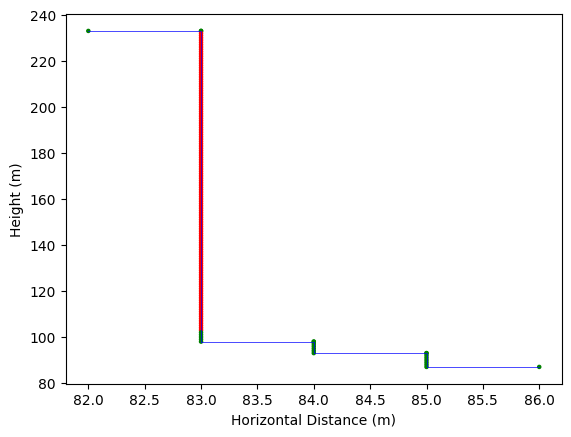

In [131]:
# NOTE: Run previous section code first

import matplotlib.pyplot as plt
colors = np.array(['red', 'green'])
plt.scatter(np.array(hdist_list[63:217]), np.array(height_list[63:217]), s=5, color=colors[np.array(rel_maintain[63:217]).astype(int)]) 
plt.plot(np.array(hdist_list[63:217]), np.array(height_list[63:217]), linewidth=0.5, color='blue')
# plt.xlim(80, 100)
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Height (m)")

In [123]:
np.where(np.array(height_list) == 233.0)

(array([ 63,  64,  65, 363, 371]),)

In [122]:
np.where(np.array(height_list) == 87.0)

(array([215, 216, 217]),)

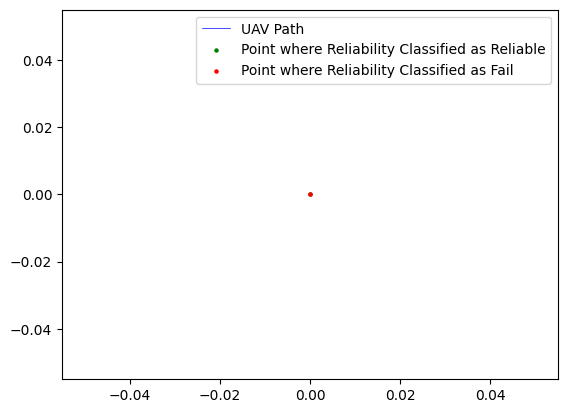

In [133]:
plt.plot(0,0,'blue', linewidth=0.5,)
plt.scatter(0,0,s=5,color='green')
plt.scatter(0,0,s=5,color='red')
plt.legend(['UAV Path', 'Point where Reliability Classified as Reliable', 'Point where Reliability Classified as Fail'])